In [2]:
# Regular EDA (exploratory data analysis) and plotting libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Models from Scikit-learn
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [3]:
df_raw = pd.read_csv("../data/final_test.csv")
df_raw.head()

,weight,age,height,size
0,62,28.0,172.72,XL
1,59,36.0,167.64,L
2,61,34.0,165.10,M
3,65,27.0,175.26,L
4,62,45.0,172.72,M


In [4]:
df_raw.shape

(119734, 4)

In [5]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 119734 entries, 0 to 119733
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   weight  119734 non-null  int64  
 1   age     119477 non-null  float64
 2   height  119404 non-null  float64
 3   size    119734 non-null  str    
dtypes: float64(2), int64(1), str(1)
memory usage: 3.7 MB


In [6]:
df_raw.describe()

,weight,age,height
count,119734.000000,119477.000000,119404.000000
mean,61.756811,34.027311,165.805794
std,9.944863,8.149447,6.737651
min,22.000000,0.000000,137.160000
25%,55.000000,29.000000,160.020000
50%,61.000000,32.000000,165.100000
75%,67.000000,37.000000,170.180000
max,136.000000,117.000000,193.040000


In [7]:
#number of occurences for each size (target variable)
df_raw["size"].value_counts()

size
M       29712
S       21924
XXXL    21359
XL      19119
L       17587
XXS      9964
XXL        69
Name: count, dtype: int64

In [8]:
df_raw.drop(df_raw[(df_raw['size'] == 'XXS') | (df_raw['size'] == 'XXL')].index, inplace=True)
df_raw["size"].value_counts()

size
M       29712
S       21924
XXXL    21359
XL      19119
L       17587
Name: count, dtype: int64

In [9]:
df_raw.shape

(109701, 4)

<Axes: xlabel='size', ylabel='count'>

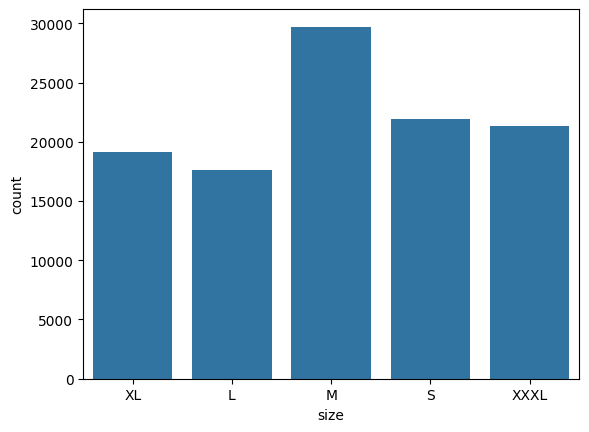

In [10]:
sns.countplot(x=df_raw['size'])

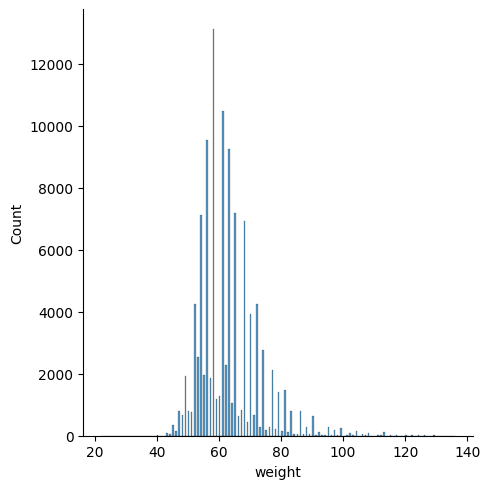

In [11]:
sns.displot(df_raw["weight"])

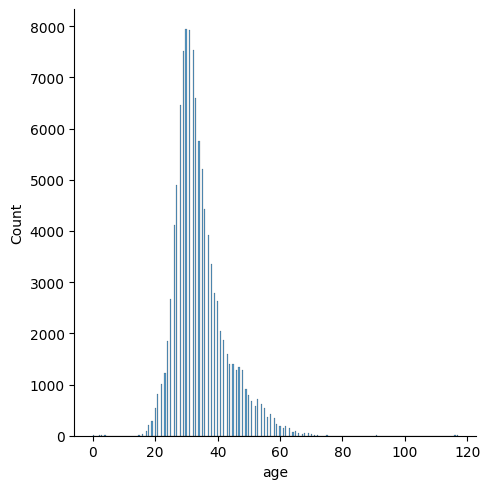

In [12]:
sns.displot(df_raw["age"])

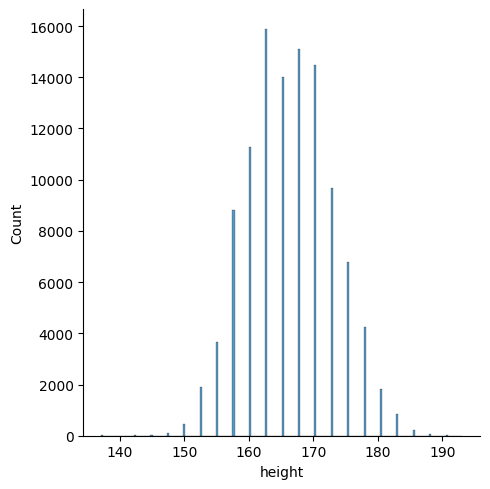

In [13]:
sns.displot(df_raw["height"])

In [14]:
df_raw.isna().sum()

weight      0
age       237
height    292
size        0
dtype: int64

In [15]:
#Filling missing data
df_raw["age"] = df_raw["age"].fillna(df_raw['age'].median())
df_raw["height"] = df_raw["height"].fillna(df_raw['height'].median())
df_raw["weight"] = df_raw["weight"].fillna(df_raw['weight'].median())

In [16]:
df_raw.isna().sum()

weight    0
age       0
height    0
size      0
dtype: int64

In [17]:
dfs_original = []  # Store original data
sizes = []
mean_by_size = {}
std_by_size = {}

for size_type in df_raw['size'].unique():
    sizes.append(size_type)
    
    # Extract data for this size
    ndf = df_raw[['age','height','weight']][df_raw['size'] == size_type].copy()
    
    # Calculate z-scores for outlier detection
    zscore = ((ndf - ndf.mean()) / ndf.std())
    
    # Save statistics
    mean_by_size[size_type] = ndf.mean()
    std_by_size[size_type] = ndf.std()
    
    # Create mask: keep rows where ALL features are within -3 to +3 std
    mask = (
        (zscore['age'] > -3) & (zscore['age'] < 3) &
        (zscore['height'] > -3) & (zscore['height'] < 3) &
        (zscore['weight'] > -3) & (zscore['weight'] < 3)
    )
    
    # Apply mask to ORIGINAL data (not z-scored)
    ndf_filtered = ndf[mask].copy()
    ndf_filtered['size'] = size_type
    
    dfs_original.append(ndf_filtered)

# Combine all sizes back together
df_raw = pd.concat(dfs_original, ignore_index=True)

print(f"Data shape after outlier removal: {df_raw.shape}")
print(f"\nClass distribution:")
print(df_raw['size'].value_counts())
df_raw.head()


Data shape after outlier removal: (107178, 4)

Class distribution:
size
M       29068
S       21423
XXXL    20751
XL      18759
L       17177
Name: count, dtype: int64


,age,height,weight,size
0,28.0,172.72,62,XL
1,29.0,177.80,74,XL
2,32.0,160.02,64,XL
3,31.0,154.94,58,XL
4,36.0,162.56,68,XL


In [18]:
df_raw['size'] = df_raw['size'].map({"S": 1,
                                    "M": 2,
                                    "L": 3,
                                    "XL": 4,
                                    "XXXL": 5})

In [19]:
df_raw['bmi'] = df_raw['height']/df_raw['weight']
df_raw['weight-squared'] = df_raw['weight'] * df_raw['weight']

In [20]:
df_raw.head()

,age,height,weight,size,bmi,weight-squared
0,28.0,172.72,62,4,2.785806,3844
1,29.0,177.80,74,4,2.402703,5476
2,32.0,160.02,64,4,2.500313,4096
3,31.0,154.94,58,4,2.671379,3364
4,36.0,162.56,68,4,2.390588,4624


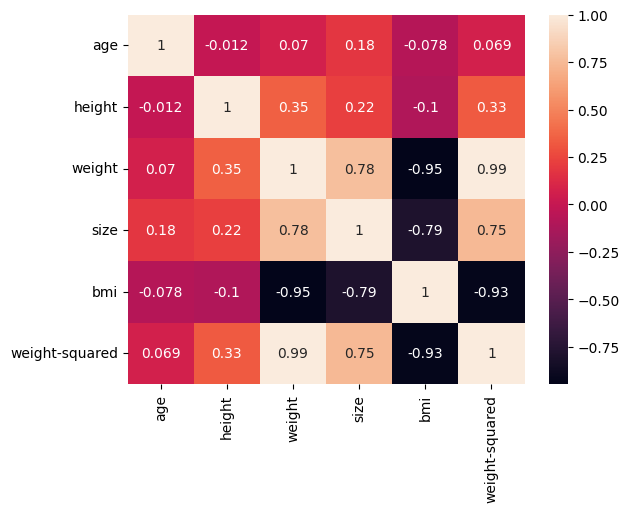

In [21]:
corr = sns.heatmap(df_raw.corr(), annot=True)

In [22]:
X = df_raw.drop(['size'], axis=1)
y = df_raw['size']

In [23]:
X.head()

,age,height,weight,bmi,weight-squared
0,28.0,172.72,62,2.785806,3844
1,29.0,177.80,74,2.402703,5476
2,32.0,160.02,64,2.500313,4096
3,31.0,154.94,58,2.671379,3364
4,36.0,162.56,68,2.390588,4624


In [24]:
y.head()

0    4
1    4
2    4
3    4
4    4
Name: size, dtype: int64

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [26]:
import pickle
 
with open('../models/features_scaler.pkl', 'wb') as f:
    model = pickle.dump(scaler, f)

In [27]:
X = pd.DataFrame(X, columns=df_raw.drop(['size'], axis=1).columns)

<Axes: >

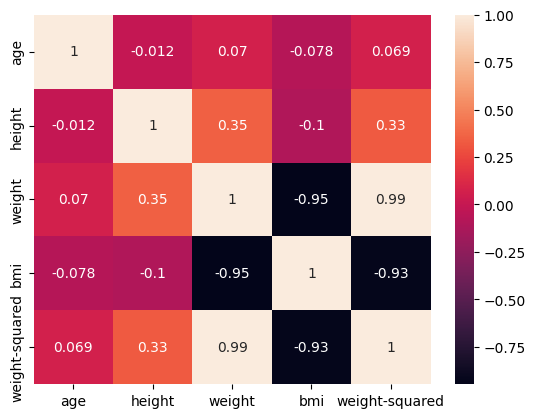

In [28]:
sns.heatmap(X.corr(), annot=True)

In [29]:
X.head()

,age,height,weight,bmi,weight-squared
0,-0.787454,0.986720,-0.065699,0.255517,-0.126769
1,-0.654168,1.756294,1.245355,-0.898557,1.176835
2,-0.254308,-0.937212,0.152810,-0.604514,0.074523
3,-0.387594,-1.706785,-0.502717,-0.089187,-0.510182
4,0.278839,-0.552426,0.589828,-0.935051,0.496277


In [30]:
y.head()

0    4
1    4
2    4
3    4
4    4
Name: size, dtype: int64

In [31]:
#splitting data into training set and validation set, testing size is 15% of the whole data
X_train, X_val, y_train, y_val, = train_test_split(X, y, test_size=0.30)

X_val, X_test, y_val, y_test, = train_test_split(X_val, y_val, test_size=0.50)

In [32]:
len(X_train), len(X_val), len(X_test)

(75024, 16077, 16077)

In [33]:
#MLP sesudah
from sklearn.neural_network import MLPClassifier

# MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000)

# Melatih model
mlp.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [34]:
from sklearn.metrics import accuracy_score

val_pred = mlp.predict(X_val)
val_acc = accuracy_score(y_val, val_pred)

print("Validation Accuracy:", val_acc)

Validation Accuracy: 0.547054798780867


In [35]:
print(classification_report(y_val, val_pred))

              precision    recall  f1-score   support

           1       0.67      0.60      0.63      3193
           2       0.49      0.65      0.56      4377
           3       0.36      0.14      0.20      2588
           4       0.40      0.46      0.43      2806
           5       0.74      0.78      0.76      3113

    accuracy                           0.55     16077
   macro avg       0.53      0.52      0.52     16077
weighted avg       0.54      0.55      0.53     16077



In [36]:
test_pred = mlp.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.5534614666915469


In [37]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           1       0.68      0.61      0.64      3248
           2       0.49      0.65      0.56      4399
           3       0.36      0.13      0.20      2512
           4       0.41      0.47      0.44      2817
           5       0.75      0.78      0.77      3101

    accuracy                           0.55     16077
   macro avg       0.54      0.53      0.52     16077
weighted avg       0.55      0.55      0.54     16077



In [38]:
import pickle

with open('../models/mlp_model.pkl', 'wb') as f:
    pickle.dump(mlp, f)

In [39]:
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi dan melatih model Decision Tree
dt_model = DecisionTreeClassifier()

# Melakukan training
dt_model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [40]:
val_pred = dt_model.predict(X_val)
val_acc = accuracy_score(y_val, val_pred)

print("Validation Accuracy:", val_acc)

Validation Accuracy: 0.5418299433974


In [41]:
print(classification_report(y_val, val_pred))

              precision    recall  f1-score   support

           1       0.62      0.63      0.63      3193
           2       0.48      0.60      0.53      4377
           3       0.37      0.26      0.30      2588
           4       0.43      0.42      0.43      2806
           5       0.78      0.71      0.75      3113

    accuracy                           0.54     16077
   macro avg       0.54      0.52      0.53     16077
weighted avg       0.54      0.54      0.54     16077



In [42]:
test_pred = dt_model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.5453753809790384


In [43]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           1       0.64      0.65      0.64      3248
           2       0.49      0.60      0.54      4399
           3       0.36      0.27      0.31      2512
           4       0.43      0.41      0.42      2817
           5       0.77      0.71      0.74      3101

    accuracy                           0.55     16077
   macro avg       0.54      0.53      0.53     16077
weighted avg       0.54      0.55      0.54     16077



In [44]:
import pickle

with open('../models/decision_tree_model.pkl', 'wb') as f:
    pickle.dump(dt_model, f)



MLP Classifier:
  Train Accuracy: 55.78%
  Val Accuracy:   54.71%
  Test Accuracy:  55.35%

Decision Tree:
  Train Accuracy: 62.29%
  Val Accuracy:   54.18%
  Test Accuracy:  54.54%



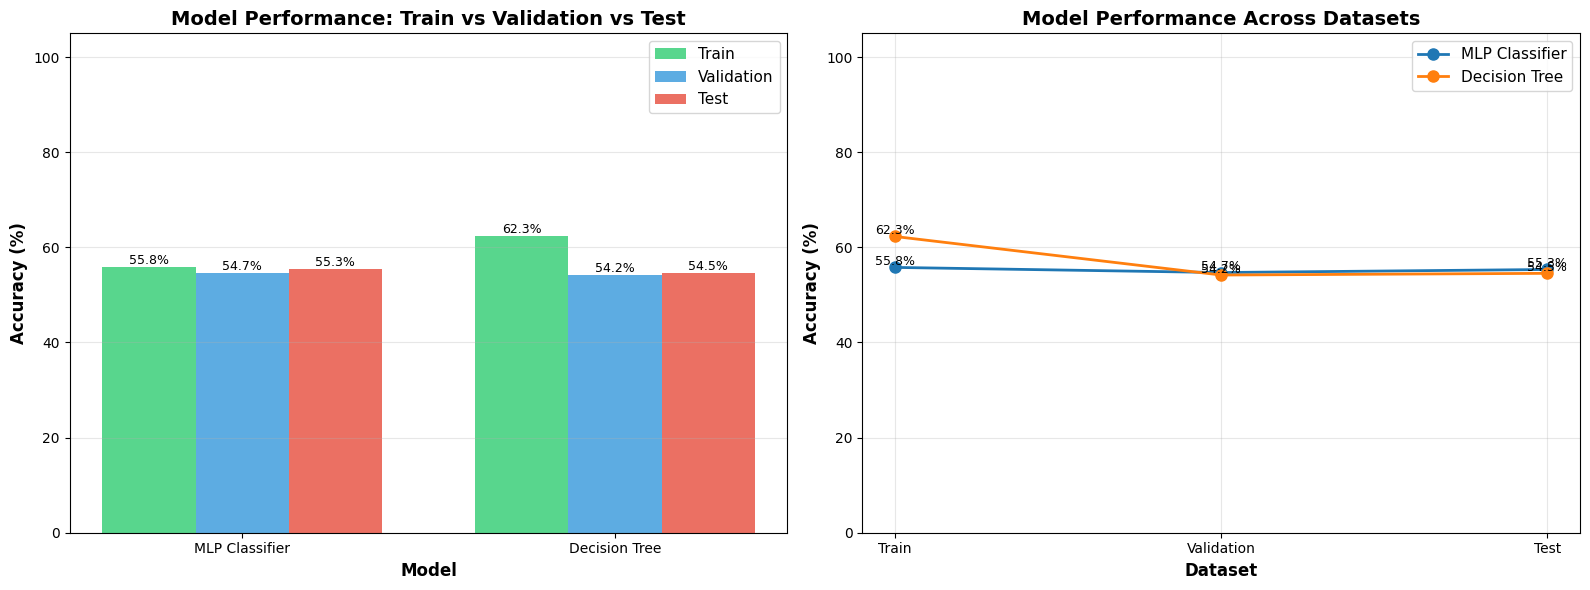

In [45]:
# from sklearn.model_selection import cross_val_score

# # Melakukan cross validation pada model MLP Classifier
# mlp_scores = cross_val_score(mlp, X_train, y_train, cv=10)

# # Melakukan cross validation pada model Decision Tree
# dt_scores = cross_val_score(dt_model, X_train, y_train, cv=10)

# # Menampilkan hasil cross validation untuk masing-masing model
# print("Hasil Cross Validation Model MLP Classifier: {:.2f}%".format(mlp_scores.mean() * 100))
# print("Hasil Cross Validation Model Decision Tree: {:.2f}%".format(dt_scores.mean() * 100))
print("\n" + "="*60 + "\n")

# Calculate accuracies for all datasets
models = {
    'MLP Classifier': mlp,
    'Decision Tree': dt_model
}

results = {
    'Model': [],
    'Train Accuracy': [],
    'Validation Accuracy': [],
    'Test Accuracy': []
}

for model_name, model in models.items():
    # Train accuracy
    train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_pred)
    
    # Validation accuracy
    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    
    # Test accuracy
    test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    
    results['Model'].append(model_name)
    results['Train Accuracy'].append(train_acc * 100)
    results['Validation Accuracy'].append(val_acc * 100)
    results['Test Accuracy'].append(test_acc * 100)
    
    print(f"{model_name}:")
    print(f"  Train Accuracy: {train_acc*100:.2f}%")
    print(f"  Val Accuracy:   {val_acc*100:.2f}%")
    print(f"  Test Accuracy:  {test_acc*100:.2f}%")
    print()

# Create DataFrame for easy plotting
results_df = pd.DataFrame(results)

# Plot comparison bar chart
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
x = np.arange(len(results_df['Model']))
width = 0.25

bars1 = ax[0].bar(x - width, results_df['Train Accuracy'], width, label='Train', color='#2ecc71', alpha=0.8)
bars2 = ax[0].bar(x, results_df['Validation Accuracy'], width, label='Validation', color='#3498db', alpha=0.8)
bars3 = ax[0].bar(x + width, results_df['Test Accuracy'], width, label='Test', color='#e74c3c', alpha=0.8)

ax[0].set_xlabel('Model', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax[0].set_title('Model Performance: Train vs Validation vs Test', fontsize=14, fontweight='bold')
ax[0].set_xticks(x)
ax[0].set_xticklabels(results_df['Model'])
ax[0].legend(fontsize=11)
ax[0].set_ylim([0, 105])
ax[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9)

# Line plot
datasets = ['Train', 'Validation', 'Test']

for idx, model_name in enumerate(results_df['Model']):
    accuracies = [
        results_df.loc[idx, 'Train Accuracy'],
        results_df.loc[idx, 'Validation Accuracy'],
        results_df.loc[idx, 'Test Accuracy']
    ]
    ax[1].plot(datasets, accuracies, marker='o', linewidth=2, markersize=8, label=model_name)
    
    # Add value labels
    for i, acc in enumerate(accuracies):
        ax[1].text(i, acc + 0.5, f'{acc:.1f}%', ha='center', fontsize=9)

ax[1].set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax[1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax[1].set_title('Model Performance Across Datasets', fontsize=14, fontweight='bold')
ax[1].legend(fontsize=11)
ax[1].set_ylim([0, 105])
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
